# NWS damage surveys

After a tornado, the National Weather Service office responsible for the area
sends a team to survey the damage, rates what it finds on the Enhanced Fujita
(EF) scale, and records it in the Damage Assessment Toolkit (DAT): damage points
with the damage indicator, degree of damage, and rating; tornado tracks drawn
from the first damage to the last; and damage areas. The DAT's public ArcGIS
feature service serves the three as layers, and one query reads one layer as
GeoJSON pages of at most 2000 features.

This walkthrough pulls the tracks and damage points surveyed for 27 April 2011,
the worst day of the 2011 Super Outbreak, and maps the tracks by rating. It needs `usdata[pandas]` and matplotlib; the two files are about
1.3 MB and the run takes a few seconds.

In [1]:
import json
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-29T23:48:25+00:00
usdata 0.33.0; pandas 3.0.6


## Select

Two sources, one per layer: `layer: lines` for the tracks and `layer: points`
for the damage points. The window selects by storm time in UTC, inclusive:
`starttime` on tracks, `stormdate` on points. A tornado at 4:43 PM CDT started
at 21:43 UTC, and the outbreak's last tornadoes began after midnight UTC, so
the window runs to midday on the 28th. It starts at 00:00 UTC on the 27th
because many surveys from 2011 record only their date, stamped at midnight
UTC. `as_of` reads the service as it stood at that instant: the DAT is edited
live, and its archive lets a pinned page stay exactly what it was.

In [2]:
print(manifest.read_text())

name: april-2011-damage-surveys
sources:
  - name: tracks
    dataset: noaa:nws-damage-surveys
    # Tracks select on their start time in UTC; the outbreak's last tornadoes began
    # after midnight UTC on 28 April.
    start: 2011-04-27T00:00Z
    end: 2011-04-28T12:00Z
    # as_of reads the live-edited service as it stood then, so the pin cannot drift.
    params: {layer: lines, as_of: "2026-09-29T00:00Z"}
  - name: points
    dataset: noaa:nws-damage-surveys
    # Many 2011 points carry only their date, stamped 00:00 UTC, so the window
    # starts there too.
    start: 2011-04-27T00:00Z
    end: 2011-04-28T12:00Z
    params: {layer: points, as_of: "2026-09-29T00:00Z"}



## What arrives

One GeoJSON file per source, since neither holds more than 2000 features. The
asset id carries the layer, the window's dates, and the run of object ids the
page covers; a larger query becomes several pages, each a run of ids, so an
edit to one feature changes one page. The first pull writes
`dataset.lock.json` beside the manifest with each file's checksum.

In [3]:
result = pull(manifest)
for name in ("tracks", "points"):
    item = result.one(name)
    print(f"{name}: {item.path.name}")
    print(f"  {item.provenance.size:,} bytes, checksum {item.provenance.checksum[:23]}...")
    print(f"  properties: {item.asset.properties}")
print("Source:", result.one("tracks").provenance.source_url[:160], "...")

tracks: nws_damage_lines_20110427_20110428_315328-2742995_e2f266a26d82.geojson
  326,707 bytes, checksum sha256:dcb5e64176126157...
  properties: {'layer': 'lines', 'as_of': '2026-09-29T00:00:00Z'}
points: nws_damage_points_20110427_20110428_25491-1613587_05eb3542edfc.geojson
  1,021,335 bytes, checksum sha256:f75c618fc287c8a3...
  properties: {'layer': 'points', 'as_of': '2026-09-29T00:00:00Z'}
Source: https://services.dat.noaa.gov/arcgis/rest/services/nws_damageassessmenttoolkit/DamageViewer/FeatureServer/1/query?where=starttime+%3E%3D+TIMESTAMP+%272011-04-27 ...


## Open

There is no bundled GeoJSON reader, so `open()` refuses these files. The
standard library reads them: each feature has a geometry and a `properties`
mapping of the layer's attributes. Dates are milliseconds since 1970, in UTC.
The two layers do not share a schema: tracks have `starttime`, `endtime`,
`length`, `width`, and `wfo`; points have `stormdate`, `office`, the damage
indicator `damage_txt`, the degree of damage `dod_txt`, and `windspeed` as text.

In [4]:
def features(item) -> pd.DataFrame:
    """One row per feature: its attributes, and its GeoJSON geometry as a dict."""
    collection = json.loads(item.path.read_text())
    rows = [{**f["properties"], "geometry": f["geometry"]} for f in collection["features"]]
    return pd.DataFrame(rows)


tracks = features(result.one("tracks"))
points = features(result.one("points"))
for frame, columns in ((tracks, ["starttime", "endtime"]), (points, ["stormdate"])):
    for column in columns:
        frame[column] = pd.to_datetime(frame[column], unit="ms", utc=True)
print(f"{len(tracks)} tracks and {len(points)} damage points")
print("Track offices:", tracks["wfo"].value_counts().to_dict())
tracks[["event_id", "wfo", "efscale", "starttime", "length", "width"]].sort_values(
    "length", ascending=False
).head(6)

124 tracks and 1397 damage points
Track offices: {'HUN': 37, 'JAN': 28, 'BMX': 28, 'OHX': 23, 'JAN,MEG': 3, 'MEG': 2, 'JAN,MOB': 1, 'HUN,OHX': 1, 'LMK,OHX': 1}


,event_id,wfo,efscale,starttime,length,width
70,Cordova Tornado,BMX,EF4,2011-04-27 20:40:00+00:00,127.8000,1408
68,Tuscaloosa-Birmingham Tornado,BMX,EF4,2011-04-27 21:43:00+00:00,80.6800,2600
86,Sawyerville-Eoline Tornado,BMX,EF3,2011-04-27 22:30:00+00:00,72.1300,1760
72,Ohatchee Tornado,BMX,EF4,2011-04-27 23:28:00+00:00,71.3000,1760
73,Ohatchee Tornado,BMX,EF4,2011-04-27 23:28:00+00:00,71.3000,1760
7,,"JAN,MOB",EF4,2011-04-27 22:41:00+00:00,65.3197,0


## A first look

Every surveyed track that began in the window, colored by its EF rating, with
the damage points in grey beneath them. Coordinates are plain longitude and
latitude, stretched by the cosine of the mean latitude so distances look right.

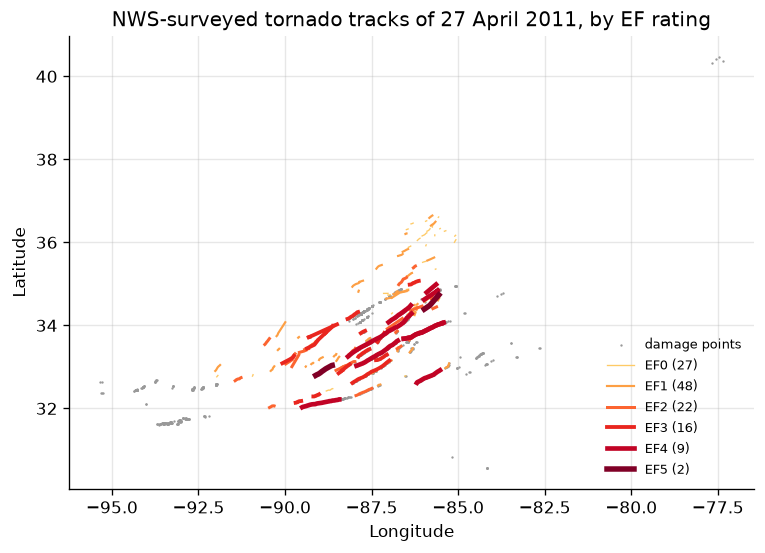

In [5]:
ratings = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5"]
colors = dict(zip(ratings, plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(ratings))), strict=True))
fig, ax = plt.subplots(layout="constrained")
xy = np.array([g["coordinates"] for g in points["geometry"]])
ax.scatter(xy[:, 0], xy[:, 1], s=2, color="0.6", linewidths=0, label="damage points")
for rating in ratings:
    rows = tracks[tracks["efscale"] == rating]
    for index, geometry in enumerate(rows["geometry"]):
        line = np.array(geometry["coordinates"])
        ax.plot(
            line[:, 0],
            line[:, 1],
            color=colors[rating],
            linewidth=0.8 + 0.5 * ratings.index(rating),
            label=f"{rating} ({len(rows)})" if index == 0 else None,
        )
ax.set_aspect(1 / np.cos(np.radians(33.5)))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="lower right", fontsize=8, frameon=False)
ax.set_title("NWS-surveyed tornado tracks of 27 April 2011, by EF rating")
plt.show()

In [6]:
summary = tracks.groupby("efscale")["length"].agg(["count", "sum", "median", "max"])
summary.columns = ["tracks", "total length", "median length", "longest"]
summary.round(1)

,tracks,total length,median length,longest
efscale,,,,
EF0,27,99.2,3.0,12.0
EF1,48,378.3,6.3,27.8
EF2,22,291.4,11.9,32.8
EF3,16,357.0,18.7,72.1
EF4,9,555.7,65.3,127.8
EF5,2,66.5,33.2,33.7


The service states no unit for `length`, but the Tuscaloosa-Birmingham EF4's
80.7 is the track length in miles that NWS Birmingham published. The EF4 tracks
are few and long: nine of them account for more path than the 75 EF0 and EF1
tracks together. Only offices that entered their surveys in the DAT appear
here, mostly Huntsville, Jackson, Birmingham, and Nashville; a track crossing
an office boundary can appear once per office or once with both named, and the
Ohatchee EF4 is here twice with the same length. The SPC and Storm Events
databases remain the official counts.

The points show the other thing to know about older surveys: most of them
carry only a date.

In [7]:
hours = points["stormdate"].dt.strftime("%Y-%m-%d %H:%M")
midnight = (hours == "2011-04-27 00:00").sum()
print(f"{midnight} of {len(points)} points are stamped 2011-04-27 00:00 UTC")
print("Most common stamps:", hours.value_counts().head(4).to_dict())

747 of 1397 points are stamped 2011-04-27 00:00 UTC
Most common stamps: {'2011-04-27 00:00': 747, '2011-04-27 06:58': 76, '2011-04-27 07:19': 65, '2011-04-27 08:38': 36}


## Pin and cite

`verify` checks the cached files against the lockfile's checksums. Because the
manifest names `as_of`, a restore asks the service's archive for the same
instant and gets the same bytes, even after the surveys are edited again.

In [8]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:nws-damage-surveys
  NOAA National Weather Service, Damage Assessment Toolkit (DamageViewer feature service), accessed via usdata
  homepage: https://apps.dat.noaa.gov/StormDamage/DamageViewer/
  license: US Government Work (public domain)
  terms: https://www.weather.gov/disclaimer
  retrieved: 2026-09-29; 2 checksummed assets (1,348,042 bytes) pinned by usdata 0.33.0
  sources: tracks, points


## What was awkward

- Storm time depends on the layer: tracks select on `starttime`, points and
  areas on `stormdate`. On tracks the two agree, except one 2011 EF4 entered in
  2026 with no `stormdate`, which is why `starttime` is used.
- Most 2011 points carry only their date, at 00:00 UTC, which is before the
  storms they record. A window that starts at the outbreak's first tornado
  misses them, so windows for older surveys have to span whole UTC days.
- There is no GeoJSON reader, so each notebook repeats the same few lines of
  `json` and pandas, and the dates arrive as epoch milliseconds.
- The tracks are not a tornado list. Coverage depends on which offices used the
  toolkit, a track can be split or repeated across offices, and the service
  calls its data preliminary. Counting tornadoes needs the SPC database.
- Nothing states the units of `length`, `width`, or `windspeed`; miles, yards,
  and mph are the NWS conventions the values match.